In [1]:
import pandas as pd
from pathlib import Path
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2025-09-04 09:27:15.468627: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-04 09:27:15.569183: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757003235.610095     873 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757003235.625068     873 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-04 09:27:15.742552: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [ ]:
images_dir = "/home/linnarelli/spis25-project-Luke-Benjamin/asl_alphabet_train"
training_dataset = tf.keras.utils.image_dataset_from_directory(
    images_dir,
    labels="inferred",
    label_mode="int",
    image_size=(256, 256),
    batch_size=32,
    seed=10,
    validation_split=0.2,
    subset="training"
)
print("huh")

testing_dataset = tf.keras.utils.image_dataset_from_directory(
    images_dir,
    labels="inferred",
    label_mode="int",
    image_size=(256, 256),
    batch_size=32,
    seed=10,
    validation_split=0.2,
    subset="validation"
)


class_names = training_dataset.class_names

num_classes = 29

model = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255),
  tf.keras.layers.Conv2D(32, kernel_size= (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, kernel_size= (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dropout(0.3),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.3),
  tf.keras.layers.Dense(num_classes, activation = 'softmax')
])

model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics = ['accuracy'])
model.fit(training_dataset, validation_data = testing_dataset, epochs = 10)

2025-09-01 09:49:01.768894: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-01 09:49:01.795916: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756745341.818380     899 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756745341.826061     899 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-01 09:49:01.856570: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Found 87000 files belonging to 29 classes.
Using 69600 files for training.


I0000 00:00:1756745350.148772     899 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


huh
Found 87000 files belonging to 29 classes.
Using 17400 files for validation.
Epoch 1/10


I0000 00:00:1756745357.160919   16782 service.cc:148] XLA service 0x7a197c0180e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756745357.161158   16782 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-09-01 09:49:17.188990: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1756745357.263065   16782 cuda_dnn.cc:529] Loaded cuDNN version 90101


   5/2175 ━━━━━━━━━━━━━━━━━━━━ 1:07 31ms/step - accuracy: 0.0339 - loss: 3.3821

I0000 00:00:1756745362.529911   16782 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 473/2175 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.0465 - loss: 3.3531

KeyboardInterrupt: 

In [8]:
model = tf.keras.models.load_model("Testing_model.keras")

images_dir = "/home/linnarelli/spis25-project-Luke-Benjamin/close_up_letters"
checking_dataset = tf.keras.utils.image_dataset_from_directory(
    images_dir,
    labels="inferred",
    label_mode="int",
    image_size=(200, 200),
    batch_size=32,
    seed=10,
)

loss, accuracy = model.evaluate(checking_dataset)
print(f"Loss: {loss}, Accuracy: {accuracy}")

Found 10 files belonging to 1 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step - accuracy: 0.0000e+00 - loss: 26.2205
Loss: 26.2204532623291, Accuracy: 0.0


Found 29 files belonging to 29 classes.
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'delete', 'nothing', 'space']
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


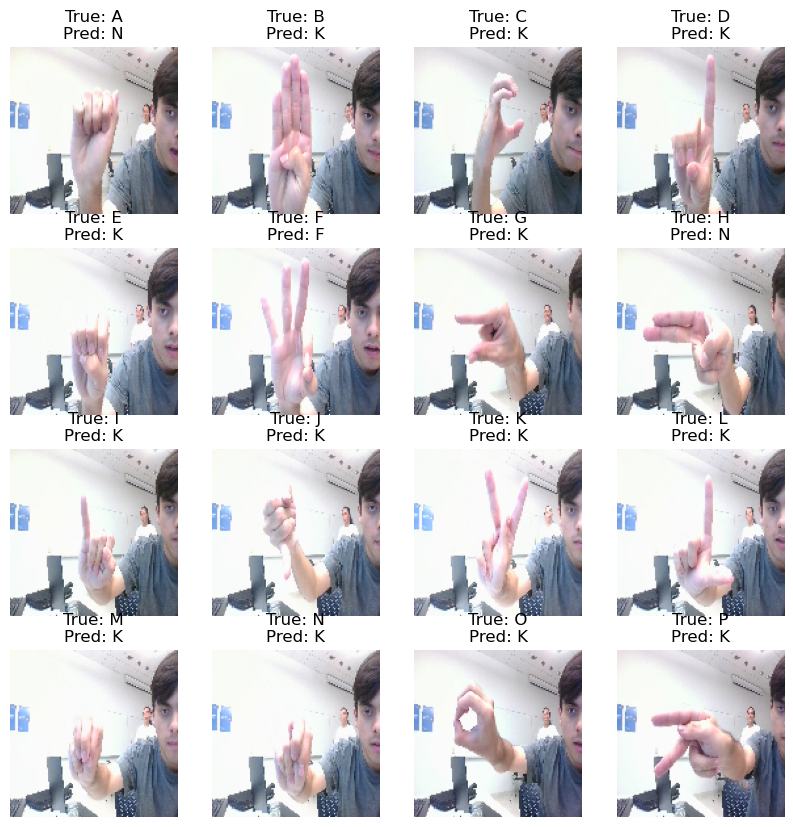

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.0690 - loss: 3.4891
Loss: 3.4891, Accuracy: 0.0690


In [11]:

model = tf.keras.models.load_model("Testing_model_with_3photos6.keras")

images_dir = "/home/linnarelli/spis25-project-Luke-Benjamin/testingData/testingData"
dataset = tf.keras.utils.image_dataset_from_directory(
    images_dir,
    labels="inferred",
    label_mode="int",
    image_size=(128,128),
    batch_size=32,
    shuffle=False,
    seed=10,
)

class_names = dataset.class_names
print(class_names)
for images, labels in dataset.take(1):  # just one batch for demonstration
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    
    plt.figure(figsize=(10, 10))
    for i in range(16):  # Show first 9 images
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = class_names[labels[i].numpy()]
        predicted_label = class_names[predicted_classes[i]]
        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis("off")
    plt.show()


loss, accuracy = model.evaluate(dataset)
print(f"Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")
# for images, labels in dataset:
#      predictions = model.predict(images)
#      predicted_classes = np.argmax(predictions, axis = 1)
#      print("Predicted class index:", predicted_classes[i])
#      print("Number of classes:", len(class_names))
#      for i in range(len(images)):
#          true_label = class_names[labels[i].numpy()]
#          predicted_label = class_names[predicted_classes[i]]
#          print(f"True: {true_label}, Predicted: {predicted_label}")
